<a href="https://colab.research.google.com/github/PushkinaAlena/ML2026_autumn/blob/main/%D0%BB%D0%B0%D0%B1%D0%B0ML2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Часть 1


Выборочная матрица ковариации:
[[ 0.21924238 -0.2380956 ]
 [-0.2380956   0.50504268]]

Теоретическая матрица ковариации:
[[ 0.2275     -0.23815699]
 [-0.23815699  0.5025    ]]

Разница:
[[-8.25762349e-03  6.13846409e-05]
 [ 6.13846409e-05  2.54268484e-03]]


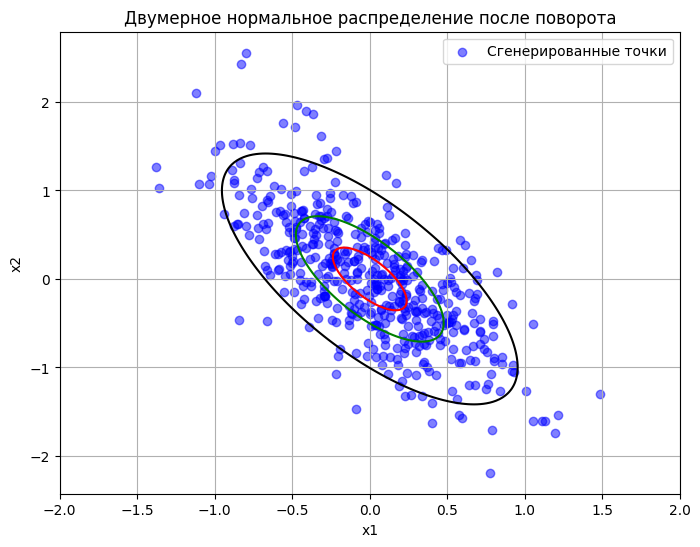

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

#Количество точек
M = 500

#Стандартные отклонения
sigma1, sigma2 = 0.3, 0.8

#Угол поворота
alpha = np.radians(30)
x1 = np.random.normal(0, sigma1, M)
x2 = np.random.normal(0, sigma2, M)

#Объединяем
X_indep = np.column_stack((x1, x2))

#Матрица поворота
R = np.array([[np.cos(alpha), -np.sin(alpha)],[np.sin(alpha),  np.cos(alpha)]])

#Поворачиваем точки
X = X_indep @ R.T

#матрица ковариации
cov_x = np.cov(X.T)

#Теоретическая матрица ковариации
C0 = np.diag([sigma1**2, sigma2**2])
c_theory = R @ C0 @ R.T

print("\nВыборочная матрица ковариации:")
print(cov_x)

print("\nТеоретическая матрица ковариации:")
print(c_theory)

print("\nРазница:")
print(cov_x - c_theory)

#Сетка для построения эллипсов
x = np.linspace(-2, 2, 200)
y = np.linspace(-2, 2, 200)
xx, yy = np.meshgrid(x, y)

#Все точки сетки объединяем
grid = np.column_stack((xx.ravel(), yy.ravel()))

#Вычисляем расстояние Махаланобиса
diff = grid - np.array([0, 0])
mahalanobis = np.sqrt(np.sum((diff @ np.linalg.inv(c_theory)) * diff, axis=1))

#Возвращаем результат к форме сетки
mahalanobis = mahalanobis.reshape(xx.shape)

#Строим график
plt.figure(figsize=(8, 6))

#Точки
plt.scatter(X[:, 0],X[:, 1],color='blue',alpha=0.5,label='Сгенерированные точки')

#Эллипсы равной плотности
plt.contour(xx,yy,mahalanobis,levels=[0.5, 1, 2],colors=['red', 'green', 'black'])

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Двумерное нормальное распределение после поворота')
plt.grid(True)
plt.legend()
plt.show()

#Часть 1.2

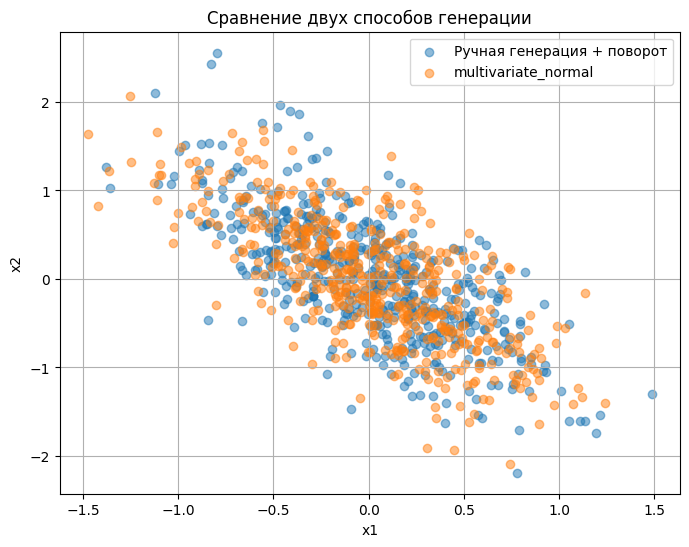

In [ ]:
#Генерируем точки
X_multi = np.random.multivariate_normal(mean=[0, 0],cov=c_theory,size=M)

#Сравниваем два облака
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0],X[:, 1],alpha=0.5,label='Ручная генерация + поворот')
plt.scatter(X_multi[:, 0],X_multi[:, 1],alpha=0.5,label='multivariate_normal')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Сравнение двух способов генерации')
plt.grid(True)
plt.legend()
plt.show()

#Часть 2


Выборочное среднее: [-0.0028338   0.00504739]

Выборочная матрица ковариации: [[ 0.21924238 -0.2380956 ]
 [-0.2380956   0.50504268]]

Максимальная разница между двумя способами: 2.220446049250313e-16


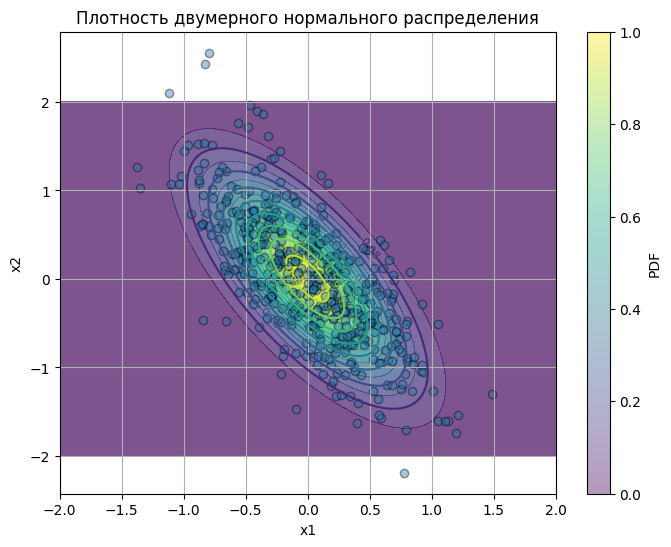

In [ ]:
#Оцениваем среднее и ковариацию по данным из части 1
mu = np.mean(X, axis=0)
C = np.cov(X.T)

print(f"Выборочное среднее: {mu}")
print(f"\nВыборочная матрица ковариации: {C}")

#Создаём сетку от -2 до 2
x = np.linspace(-2, 2, 200)
y = np.linspace(-2, 2, 200)

xx, yy = np.meshgrid(x, y)

# Превращаем сетку в список точек
grid_points = np.column_stack((xx.ravel(), yy.ravel()))

#Вычисляем PDF с помощью scipy
m = multivariate_normal(mean=mu, cov=C)
pdf_scipy = m.pdf(grid_points)

#Возвращаем PDF к форме сетк и
pdf_scipy = pdf_scipy.reshape(xx.shape)

#Вычисляем PDF вручную
det_C = np.linalg.det(C)
inv_C = np.linalg.inv(C)

diff = grid_points - mu

mahalanobis_squared = np.sum((diff @ inv_C) * diff, axis=1)

pdf_manual = (1 / (2 * np.pi * np.sqrt(det_C)) * np.exp(-0.5 * mahalanobis_squared))

#Возвращаем к форме сетки
pdf_manual = pdf_manual.reshape(xx.shape)

#Сравниваем два способа
max_diff = np.max(np.abs(pdf_manual - pdf_scipy))

print(f"\nМаксимальная разница между двумя способами: {max_diff}")

#Визуализация
plt.figure(figsize=(8, 6))

#Заливка плотности
plt.contourf(xx, yy, pdf_scipy, levels=20, alpha=0.7)

#Линии уровня
contours = plt.contour(xx, yy, pdf_scipy, levels=10)

#Подписи линий
plt.clabel(contours, inline=True, fontsize=8)

#Исходные точки
plt.scatter(X[:, 0], X[:, 1], alpha=0.4, edgecolors='black')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Плотность двумерного нормального распределения')

plt.colorbar(label='PDF')

plt.grid(True)
plt.show()

#Часть 3

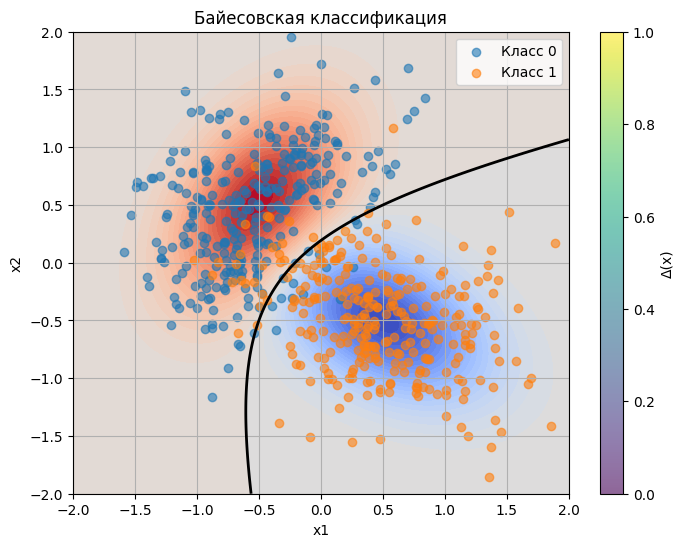

In [ ]:
#Параметры класса 0
mu0 = np.array([-0.5, 0.5])
C0 = np.array([[0.2, 0.1],[0.1, 0.3]])

#Параметры класса 1
mu1 = np.array([0.5, -0.5])
C1 = np.array([[0.3, -0.1],[-0.1, 0.2]])

#Генерируем 300 точек каждого класса
X0 = np.random.multivariate_normal(mean=mu0,cov=C0,size=300)
X1 = np.random.multivariate_normal(mean=mu1,cov=C1,size=300)

#Априорные вероятности
prior0 = len(X0) / (len(X0) + len(X1))
prior1 = len(X1) / (len(X0) + len(X1))

#Создаём распределения
dist0 = multivariate_normal(mean=mu0,cov=C0)
dist1 = multivariate_normal(mean=mu1,cov=C1)

#Создаём сетку
x = np.linspace(-2, 2, 300)
y = np.linspace(-2, 2, 300)
xx, yy = np.meshgrid(x, y)
grid_points = np.column_stack((xx.ravel(), yy.ravel()))

#Плотность для каждого класса
pdf0 = dist0.pdf(grid_points)
pdf1 = dist1.pdf(grid_points)

#Вычисляем Δ(x)
delta = pdf0 * prior0 - pdf1 * prior1

#Возвращаем Δ к форме сетки
delta_grid = delta.reshape(xx.shape)

#Строим фон
plt.figure(figsize=(8, 6))
plt.contourf(xx,yy,delta_grid,levels=50,cmap='coolwarm')

#Разделяющая поверхность Δ(x) = 0
plt.contour(xx,yy,delta_grid,levels=[0],colors='black',linewidths=2)

#Реальные точки класса 0
plt.scatter(X0[:, 0],X0[:, 1],label='Класс 0',alpha=0.6)

# Реальные точки класса 1
plt.scatter(X1[:, 0],X1[:, 1],label='Класс 1',alpha=0.6)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Байесовская классификация')
plt.legend()
plt.colorbar(label='Δ(x)')
plt.grid(True)
plt.show()

Разделяющая поверхность не является линейной. Это связано с тем, что ковариационные матрицы двух классов различаются. Поэтому при сравнении гауссовских плотностей в уравнении Δ(x)=0 появляются квадратичные члены x1^2, x1x2 и x2^2. Следовательно, разделяющая поверхность является квадратичной.

#Часть 4.2



In [ ]:
from sklearn.base import BaseEstimator
import numpy as np

class MyLDA(BaseEstimator):

    def __init__(self):
        self.classes_ = None
        self.means_ = None
        self.priors_ = None
        self.cov_ = None
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):

        # Уникальные классы
        self.classes_ = np.unique(y)

        # Средние и априорные вероятности
        self.means_ = {}
        self.priors_ = {}

        n_features = X.shape[1]

        for c in self.classes_:
            X_c = X[y == c]

            # Среднее класса
            self.means_[c] = np.mean(X_c, axis=0)

            # Априорная вероятность
            self.priors_[c] = len(X_c) / len(X)

        # Общая ковариационная матрица
        cov = np.zeros((n_features, n_features))

        for c in self.classes_:
            X_c = X[y == c]
            diff = X_c - self.means_[c]
            cov += diff.T @ diff
        cov = cov / len(X)

        # Регуляризация
        self.cov_ = cov + 1e-6 * np.eye(n_features)

        # Обратная ковариационная матрица
        inv_cov = np.linalg.inv(self.cov_)

        # Средние двух классов
        mu0 = self.means_[0]
        mu1 = self.means_[1]

        # w
        self.coef_ = inv_cov @ (mu1 - mu0)

        # b
        self.intercept_ = (0.5 * mu0.T @ inv_cov @ mu0- 0.5 * mu1.T @ inv_cov @ mu1 + np.log(self.priors_[1] / self.priors_[0]))

        return self

    def predict(self, X):
        score = X @ self.coef_ + self.intercept_
        return (score >= 0).astype(int)

    def predict_proba(self, X):
        score = X @ self.coef_ + self.intercept_
        prob1 = 1 / (1 + np.exp(-score))
        prob0 = 1 - prob1
        return np.column_stack((prob0, prob1))

#Часть 4.3

Предсказания совпадают: True


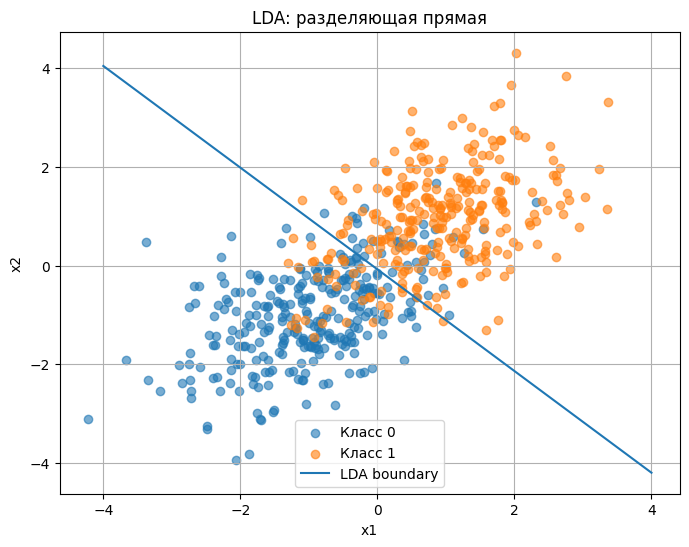

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

#Генерация данных
np.random.seed(42)
mu0 = np.array([-1.0, -1.0])
mu1 = np.array([1.0, 1.0])
C = np.array([
    [1.0, 0.5],
    [0.5, 1.0]
])

X0 = np.random.multivariate_normal(mean=mu0,cov=C,size=300)
X1 = np.random.multivariate_normal(mean=mu1,cov=C,size=300)

#Объединение данных
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(300, dtype=int),np.ones(300, dtype=int)])

#Train / test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

#Обучение my LDA
my_lda = MyLDA().fit(X_train, y_train)

#Обучение sklearn LDA
sk_lda = LinearDiscriminantAnalysis().fit(X_train,y_train)

#Сравнение предсказаний
pred_my = my_lda.predict(X_test)
pred_sk = sk_lda.predict(X_test)

print("Предсказания совпадают:",np.allclose(pred_my, pred_sk))

#Визуализация
plt.figure(figsize=(8, 6))
plt.scatter(X0[:, 0],X0[:, 1],label='Класс 0',alpha=0.6)
plt.scatter(X1[:, 0],X1[:, 1],label='Класс 1',alpha=0.6)

# Разделяющая прямая
x1_grid = np.linspace(-4, 4, 200)
w1 = my_lda.coef_[0]
w2 = my_lda.coef_[1]
b = my_lda.intercept_
x2_grid = -(w1 * x1_grid + b) / w2

plt.plot(x1_grid,x2_grid,label='LDA boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('LDA: разделяющая прямая')
plt.legend()
plt.grid(True)
plt.show()

#Часть 5

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB


# ============================================================
# 1. Создаём синтетические данные
# ============================================================

np.random.seed(42)

# Средние двух классов
mu0 = np.array([-1.0, -1.0])
mu1 = np.array([1.0, 1.0])

# Общая ковариационная матрица
C = np.array([
    [1.0, 0.5],
    [0.5, 1.0]
])

# 300 объектов каждого класса
X0 = np.random.multivariate_normal(
    mean=mu0,
    cov=C,
    size=300
)

X1 = np.random.multivariate_normal(
    mean=mu1,
    cov=C,
    size=300
)


# ============================================================
# 2. Объединяем данные
# ============================================================

X = np.vstack([X0, X1])

y = np.hstack([
    np.zeros(300, dtype=int),
    np.ones(300, dtype=int)
])


# ============================================================
# 3. Делим данные на train и test
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ============================================================
# 4. Реализация Naive Bayes
# ============================================================

class MyNB(BaseEstimator):

    def __init__(self):
        self.classes_ = None
        self.means_ = None
        self.vars_ = None
        self.priors_ = None

    # --------------------------------------------------------
    # Обучение модели
    # --------------------------------------------------------

    def fit(self, X, y):

        # Уникальные классы
        self.classes_ = np.unique(y)

        # Словари для параметров
        self.means_ = {}
        self.vars_ = {}
        self.priors_ = {}

        # Для каждого класса
        for c in self.classes_:

            # Выбираем объекты данного класса
            X_c = X[y == c]

            # Среднее каждого признака
            self.means_[c] = np.mean(
                X_c,
                axis=0
            )

            # Дисперсия каждого признака
            self.vars_[c] = np.var(
                X_c,
                axis=0
            )

            # Априорная вероятность класса
            self.priors_[c] = len(X_c) / len(X)

        return self

    # --------------------------------------------------------
    # Предсказание класса
    # --------------------------------------------------------

    def predict(self, X):

        # Здесь будем хранить score для каждого класса
        log_scores = []

        # Считаем score для каждого класса
        for c in self.classes_:

            # Средние признаков этого класса
            mu = self.means_[c]

            # Дисперсии признаков этого класса
            var = self.vars_[c]

            # Логарифмический score:
            #
            # log P(c)
            # - 1/2 * sum[
            #     log(2*pi*var)
            #     + (X-mu)^2 / var
            # ]

            log_score = (
                np.log(self.priors_[c])
                - 0.5 * np.sum(
                    np.log(2 * np.pi * var)
                    + (X - mu) ** 2 / var,
                    axis=1
                )
            )

            # Добавляем score данного класса
            log_scores.append(log_score)

        # Превращаем список в матрицу:
        #
        # строки = объекты
        # столбцы = классы
        #
        # Например:
        # [[score_0, score_1],
        #  [score_0, score_1],
        #  ...]

        log_scores = np.column_stack(log_scores)

        # Для каждого объекта выбираем класс
        # с максимальным score
        return self.classes_[
            np.argmax(log_scores, axis=1)
        ]


# ============================================================
# 5. Обучаем собственный Naive Bayes
# ============================================================

my_nb = MyNB().fit(
    X_train,
    y_train
)


# ============================================================
# 6. Обучаем GaussianNB из sklearn
# ============================================================

sk_nb = GaussianNB().fit(
    X_train,
    y_train
)


# ============================================================
# 7. Получаем предсказания
# ============================================================

pred_my = my_nb.predict(X_test)

pred_sk = sk_nb.predict(X_test)


# ============================================================
# 8. Сравниваем предсказания
# ============================================================

print(
    "Предсказания MyNB:",
    pred_my
)

print(
    "Предсказания sklearn:",
    pred_sk
)

print(
    "Предсказания совпадают:",
    np.allclose(pred_my, pred_sk)
)


# Автоматическая проверка из задания
assert np.allclose(
    pred_my,
    pred_sk
), "Предсказания NB не совпадают"

In [ ]:
import numpy as np
from sklearn.base import BaseEstimator
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

class MyNB(BaseEstimator):

    def __init__(self):
        self.classes_ = None
        self.means_ = None
        self.vars_ = None
        self.priors_ = None

    def fit(self, X, y):

        #Классы
        self.classes_ = np.unique(y)

        self.means_ = {}
        self.vars_ = {}
        self.priors_ = {}

        #Параметры каждого класса
        for c in self.classes_:
            X_c = X[y == c]
            self.means_[c] = np.mean(X_c,axis=0)
            self.vars_[c] = np.var(X_c,axis=0) # диагональ ковариации
            self.priors_[c] = len(X_c) / len(X)

        return self

    # Предсказание
    def predict(self, X):
        log_scores = []

        for c in self.classes_:
            mu = self.means_[c]
            var = self.vars_[c]
            prior = self.priors_[c]
            log_score = (np.log(prior) - 0.5 * np.sum(np.log(2 * np.pi * var) + (X - mu) ** 2 / var,axis=1))
            log_scores.append(log_score)

        # Объединяем score
        log_scores = np.column_stack(log_scores)

        # Выбираем максимум
        return self.classes_[np.argmax(log_scores, axis=1)]

# Создание данных
np.random.seed(42)
mu0 = np.array([-1.0, -1.0])
mu1 = np.array([1.0, 1.0])
C = np.array([
    [1.0, 0.5],
    [0.5, 1.0]
])

X0 = np.random.multivariate_normal(mean=mu0,cov=C,size=300)
X1 = np.random.multivariate_normal(mean=mu1,cov=C,size=300)

# Объединяем данные
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(300, dtype=int),np.ones(300, dtype=int)])

# Делим на train и test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# Обучаем MyNB
my_nb = MyNB().fit(X_train,y_train)

# Обучаем sklearn
sk_nb = GaussianNB().fit(X_train,y_train)

# Предсказания
pred_my = my_nb.predict(X_test)
pred_sk = sk_nb.predict(X_test)

print("Предсказания совпадают:",np.allclose(pred_my, pred_sk))

# Проверка из задания
assert np.allclose(pred_my,pred_sk), "Предсказания NB не совпадают"

Предсказания совпадают: True


#Часть 6

  Dataset   Model  Accuracy  Precision_0  Precision_1  Precision_macro  \
0       A   MyLDA  0.962500     0.982609     0.944000         0.963304   
1       A    MyNB  0.925000     0.981132     0.880597         0.930865   
2       A  LogReg  0.958333     0.982456     0.936508         0.959482   
3       B   MyLDA  0.745833     0.756522     0.736000         0.746261   
4       B    MyNB  0.754167     0.779817     0.732824         0.756320   
5       B  LogReg  0.758333     0.762712     0.754098         0.758405   
6       C   MyLDA  0.712500     0.742857     0.688889         0.715873   
7       C    MyNB  0.783333     0.742857     0.840000         0.791429   
8       C  LogReg  0.704167     0.728972     0.684211         0.706591   

   Recall_0  Recall_1  Recall_macro      F1_0      F1_1  F1_macro  
0  0.941667  0.983333      0.962500  0.961702  0.963265  0.962484  
1  0.866667  0.983333      0.925000  0.920354  0.929134  0.924744  
2  0.933333  0.983333      0.958333  0.957265  0.959350

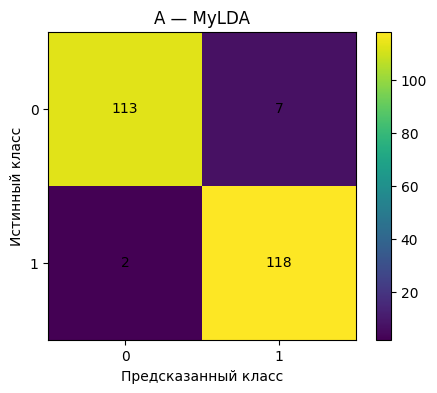


Датасет A, модель MyNB
[[104  16]
 [  2 118]]


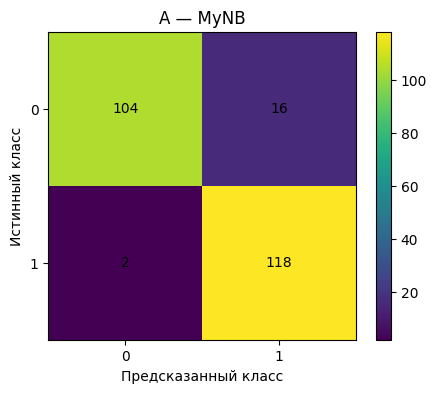


Датасет A, модель LogReg
[[112   8]
 [  2 118]]


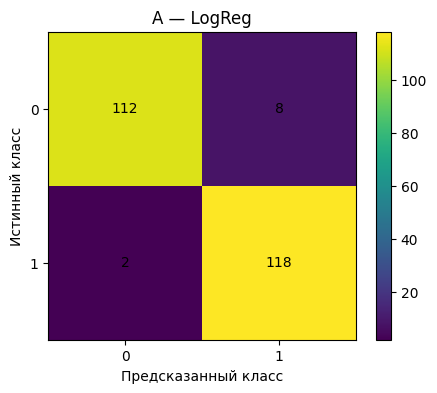


Датасет B, модель MyLDA
[[87 33]
 [28 92]]


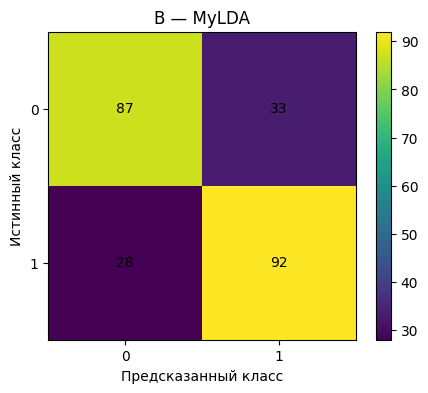


Датасет B, модель MyNB
[[85 35]
 [24 96]]


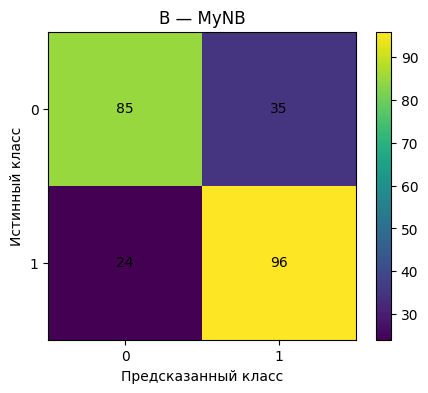


Датасет B, модель LogReg
[[90 30]
 [28 92]]


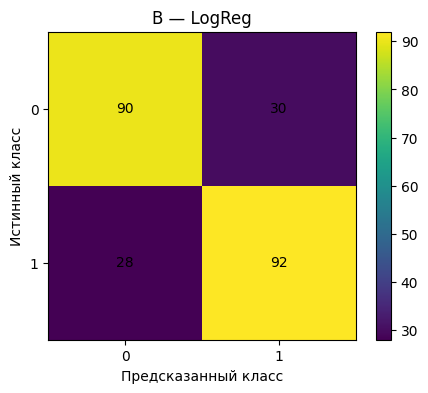


Датасет C, модель MyLDA
[[78 42]
 [27 93]]


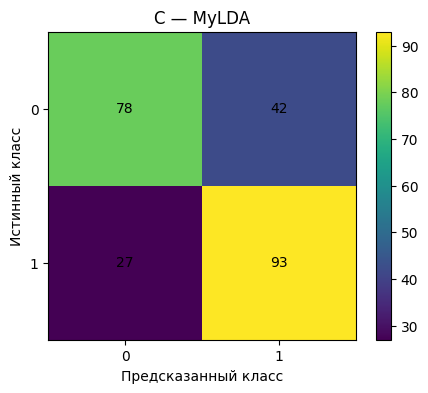


Датасет C, модель MyNB
[[104  16]
 [ 36  84]]


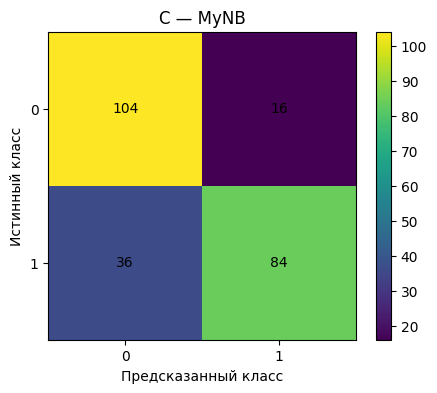


Датасет C, модель LogReg
[[78 42]
 [29 91]]


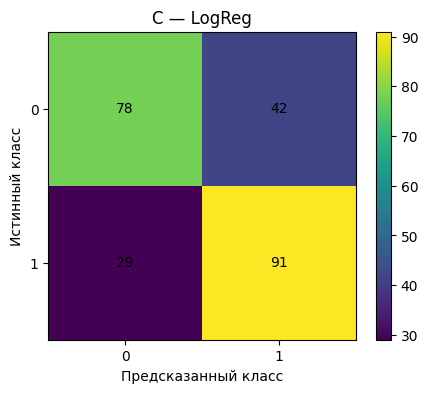

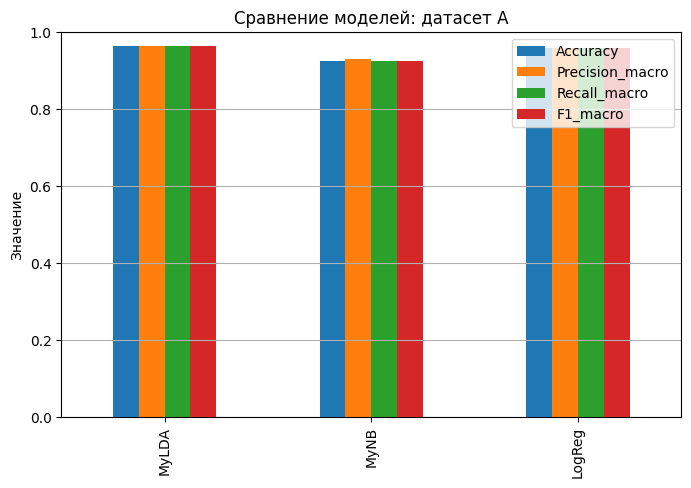

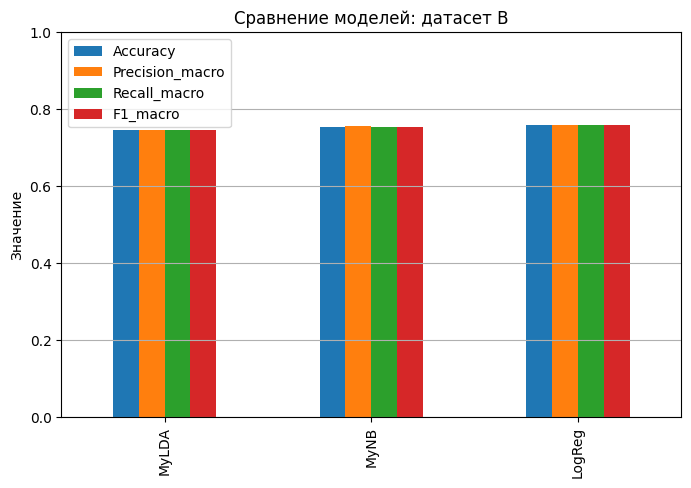

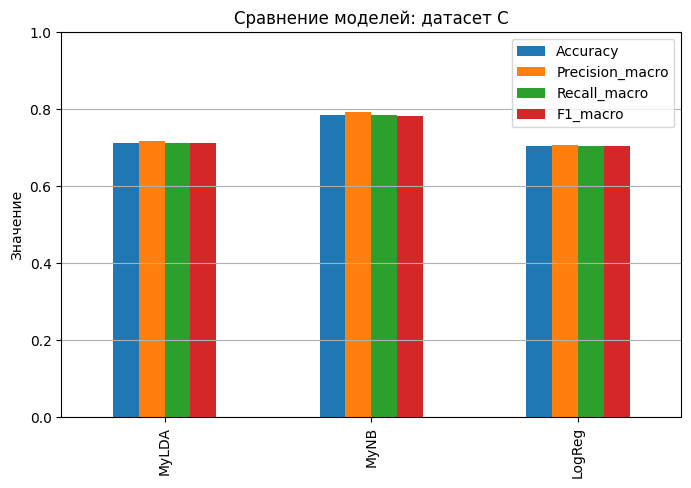

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Метрики
def get_metrics(y_true, y_pred):

    precision = precision_score(
        y_true,
        y_pred,
        labels=[0, 1],
        average=None,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        labels=[0, 1],
        average=None,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        labels=[0, 1],
        average=None,
        zero_division=0
    )

    return {
        'Accuracy': accuracy_score(y_true, y_pred),

        'Precision_0': precision[0],
        'Precision_1': precision[1],
        'Precision_macro': precision_score(
            y_true,
            y_pred,
            average='macro',
            zero_division=0
        ),

        'Recall_0': recall[0],
        'Recall_1': recall[1],
        'Recall_macro': recall_score(
            y_true,
            y_pred,
            average='macro',
            zero_division=0
        ),

        'F1_0': f1[0],
        'F1_1': f1[1],
        'F1_macro': f1_score(
            y_true,
            y_pred,
            average='macro',
            zero_division=0
        )
    }

# Один эксперимент
def run_experiment(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    models = {
        'MyLDA': MyLDA(),
        'MyNB': MyNB(),
        'LogReg': LogisticRegression(max_iter=2000)
    }

    results = {}
    matrices = {}

    for name, model in models.items():

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        results[name] = get_metrics(
            y_test,
            y_pred
        )

        matrices[name] = confusion_matrix(
            y_test,
            y_pred
        )

    return results, matrices

# Создание датасета A
X_A, y_A = make_classification(
    n_samples=1200,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_clusters_per_class=1,
    class_sep=1.0,
    flip_y=0.0,
    random_state=2
)

# Создание датасета B
X_B, y_B = make_classification(
    n_samples=1200,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_clusters_per_class=3,
    class_sep=0.4,
    flip_y=0.0,
    random_state=2
)

# Создание датасета C
X_C, y_C = make_classification(
    n_samples=1200,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_clusters_per_class=2,
    class_sep=0.5,
    flip_y=0.05,
    random_state=3
)

# Все датасеты
datasets = {
    'A': (X_A, y_A),
    'B': (X_B, y_B),
    'C': (X_C, y_C)
}

# Эксперименты
all_results = {}
all_matrices = {}

for name, (X, y) in datasets.items():

    results, matrices = run_experiment(
        X,
        y
    )

    all_results[name] = results
    all_matrices[name] = matrices

# Таблица результатов
rows = []

for dataset_name in all_results:

    for model_name in all_results[dataset_name]:

        row = {
            'Dataset': dataset_name,
            'Model': model_name
        }

        row.update(
            all_results[dataset_name][model_name]
        )

        rows.append(row)


results_df = pd.DataFrame(rows)

print(results_df)

# Confusion matrix
for dataset_name in all_matrices:

    for model_name in all_matrices[dataset_name]:

        cm = all_matrices[dataset_name][model_name]

        print(
            f'\nДатасет {dataset_name}, модель {model_name}'
        )

        print(cm)

        plt.figure(figsize=(5, 4))

        plt.imshow(cm)

        plt.xticks(
            [0, 1],
            ['0', '1']
        )

        plt.yticks(
            [0, 1],
            ['0', '1']
        )

        plt.xlabel('Предсказанный класс')
        plt.ylabel('Истинный класс')

        plt.title(
            f'{dataset_name} — {model_name}'
        )

        for i in range(2):

            for j in range(2):

                plt.text(
                    j,
                    i,
                    cm[i, j],
                    ha='center',
                    va='center'
                )

        plt.colorbar()
        plt.show()

# Графики метрик
metrics = [
    'Accuracy',
    'Precision_macro',
    'Recall_macro',
    'F1_macro'
]

for dataset_name in all_results:

    df = pd.DataFrame(
        all_results[dataset_name]
    ).T

    df[metrics].plot(
        kind='bar',
        figsize=(8, 5)
    )

    plt.title(
        f'Сравнение моделей: датасет {dataset_name}'
    )

    plt.ylabel('Значение')
    plt.ylim(0, 1)
    plt.grid(axis='y')
    plt.legend()
    plt.show()